In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print('All imports successful')

All imports successful


In [ ]:
df = pd.read_csv('../data/processed/telco_churn_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('\nClass distribution (before SMOTE):')
print(y.value_counts())
print(f'Churn rate: {y.mean():.2%}')

Feature matrix shape: (7032, 19)
Target shape: (7032,)

Class distribution (before SMOTE):
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn rate: 26.58%


In [ ]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print('Categorical columns to encode:', categorical_cols)
print('\nNumerical columns to scale:', numerical_cols)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns to scale: ['tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print('Shape before encoding:', X.shape)
print('Shape after encoding:', X_encoded.shape)
print('\nNew columns added:')
new_cols = [c for c in X_encoded.columns if c not in X.columns]
print(new_cols)

Shape before encoding: (7032, 19)
Shape after encoding: (7032, 30)

New columns added:
['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [ ]:
print('Any non-numeric columns remaining?')
non_numeric = X_encoded.select_dtypes(include='object').columns.tolist()
print(non_numeric if non_numeric else 'None - all columns are numeric. Ready for modelling.')

Any non-numeric columns remaining?
None — all columns are numeric. Ready for modelling.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('\nChurn rate in training set:', y_train.mean().round(4))
print('Churn rate in test set:', y_test.mean().round(4))
print('(These should be close to each other - stratify is working)')

Training set shape: (5625, 30)
Test set shape: (1407, 30)

Churn rate in training set: 0.2658
Churn rate in test set: 0.2658
(These should be close to each other — stratify is working)


In [ ]:
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print('Scaling complete.')
print('\nTraining set - numerical column stats after scaling:')
print(X_train[numerical_cols].describe().round(3))
print('\n(Mean should be ~0, std should be ~1 for each column)')

Scaling complete.

Training set — numerical column stats after scaling:
         tenure  MonthlyCharges  TotalCharges
count  5625.000        5625.000      5625.000
mean     -0.000           0.000         0.000
std       1.000           1.000         1.000
min      -1.286          -1.548        -1.003
25%      -0.960          -0.970        -0.830
50%      -0.145           0.186        -0.392
75%       0.955           0.832         0.659
max       1.607           1.782         2.805

(Mean should be ~0, std should be ~1 for each column)


In [ ]:
print('Class distribution BEFORE SMOTE:')
print(y_train.value_counts())
print(f'Churn rate: {y_train.mean():.2%}')

Class distribution BEFORE SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64
Churn rate: 26.58%


In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Class distribution AFTER SMOTE:')
print(pd.Series(y_train_sm).value_counts())
print(f'Churn rate: {pd.Series(y_train_sm).mean():.2%}')
print(f'\nTraining set size: {len(X_train)} → {len(X_train_sm)} rows')

Class distribution AFTER SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64
Churn rate: 50.00%

Training set size: 5625 → 8260 rows


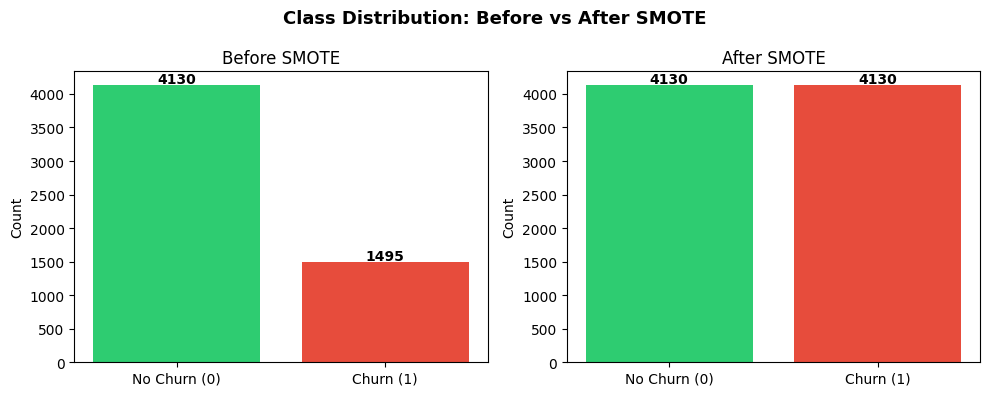

Plot saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
before_counts = y_train.value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], 
            [before_counts[0], before_counts[1]],
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate([before_counts[0], before_counts[1]]):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# After SMOTE
after_counts = pd.Series(y_train_sm).value_counts()
axes[1].bar(['No Churn (0)', 'Churn (1)'],
            [after_counts[0], after_counts[1]],
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate([after_counts[0], after_counts[1]]):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/smote_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)


X_train_sm_df = pd.DataFrame(X_train_sm, columns=X_encoded.columns)
y_train_sm_series = pd.Series(y_train_sm, name='Churn')

X_train_sm_df.to_csv('../data/processed/X_train.csv', index=False)
y_train_sm_series.to_csv('../data/processed/y_train.csv', index=False)

X_test.to_csv('../data/processed/X_test.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print('Saved:')
print(f'  X_train.csv - {X_train_sm_df.shape[0]} rows, {X_train_sm_df.shape[1]} features')
print(f'  y_train.csv - {len(y_train_sm_series)} labels')
print(f'  X_test.csv  - {X_test.shape[0]} rows, {X_test.shape[1]} features')
print(f'  y_test.csv  - {len(y_test)} labels')

Saved:
  X_train.csv — 8260 rows, 30 features
  y_train.csv — 8260 labels
  X_test.csv  — 1407 rows, 30 features
  y_test.csv  — 1407 labels

Day 3 complete. Ready for model training on Day 4.
